# Mean reversion & the Ornstein–Uhlenbeck process — `qufin.models`

A **mean-reverting** series wanders, but is pulled back toward a long-run level.
The canonical continuous-time model is the **Ornstein–Uhlenbeck (OU)** process:

$$ dX_t = \theta\,(\mu - X_t)\,dt + \sigma\,dW_t $$

* $\theta>0$ — **speed** of reversion (how hard the spring pulls back)
* $\mu$ — **long-run mean** (where it pulls toward)
* $\sigma$ — **diffusion** (how violently it's kicked)

The single most useful derived quantity is the **half-life**
$t_{1/2} = \ln 2/\theta$: the expected time to close half the gap to $\mu$.
A tradeable mean-reverting signal needs a half-life short enough to act on but
long enough to survive costs.

The OU process has an **exact** discrete-time solution — no Euler error — that is
just an **AR(1)**:

$$ X_{t+1} = \underbrace{\mu(1-b)}_{a} + \underbrace{e^{-\theta\Delta}}_{b}\,X_t + \varepsilon_t, \qquad \varepsilon_t\sim\mathcal N\!\big(0,\;\sigma^2\tfrac{1-b^2}{2\theta}\big) $$

so we can estimate $(\theta,\mu,\sigma)$ by a single OLS regression.

**Roadmap**

1. *Provably recovers the truth* — simulate an OU, refit, compare
2. Anatomy — path, equilibrium bands, theoretical autocorrelation
3. The z-score trading signal — entry/exit bands and reversion probabilities
4. A real mean-reverting series — the KO/PEP price ratio
5. Hand-off — the adaptive `MeanReversionStrategy`


In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np

from qufin.models.ou_process import OrnsteinUhlenbeck
from qufin.models.spread import half_life, zscore, rolling_zscore
from qufin.timeseries import adf
from qufin.strategies import MeanReversionStrategy, StrategyParams

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.grid': True,
    'grid.alpha': 0.25,
    'axes.spines.top': False,
    'axes.spines.right': False,
})


## 1. Proof it works — recover known parameters

`OrnsteinUhlenbeck(theta, mu, sigma).simulate(...)` draws an exact OU path. We
choose a **half-life of ~25 days** ($\theta=\ln 2/25$), then refit by OLS and
MLE and confirm both estimators recover $(\theta,\mu,\sigma)$ — and crucially
the half-life that a trader actually cares about.


In [2]:
HALF_LIFE = 25.0
TRUE = dict(theta=np.log(2) / HALF_LIFE, mu=100.0, sigma=1.5)
ou_true = OrnsteinUhlenbeck(**TRUE, dt=1.0)
path = ou_true.simulate(n_steps=6000, x0=100.0, seed=7)

fit_ols = OrnsteinUhlenbeck(dt=1.0); r_ols = fit_ols.fit(path, method='ols')
fit_mle = OrnsteinUhlenbeck(dt=1.0); r_mle = fit_mle.fit(path, method='mle')

print(f"{'param':>10} {'true':>10} {'OLS':>10} {'MLE':>10}")
for k in ('theta', 'mu', 'sigma'):
    print(f'{k:>10} {TRUE[k]:>10.4f} {getattr(r_ols, k):>10.4f} {getattr(r_mle, k):>10.4f}')
print(f"{'half_life':>10} {HALF_LIFE:>10.2f} {r_ols.half_life:>10.2f} {r_mle.half_life:>10.2f}")
print(f"{'sigma_eq':>10} {'':>10} {r_ols.sigma_eq:>10.4f} {r_mle.sigma_eq:>10.4f}"
      f"   (= sigma / sqrt(2 theta))")


     param       true        OLS        MLE
     theta     0.0277     0.0245     0.0245
        mu   100.0000    99.2294    99.2294
     sigma     1.5000     1.4910     1.4910
 half_life      25.00      28.31      28.31
  sigma_eq                6.7381     6.7381   (= sigma / sqrt(2 theta))


## 2. Anatomy of an OU path

Two structural facts:

* The stationary distribution is $X_\infty\sim\mathcal N(\mu,\;\sigma_{eq}^2)$
  with $\sigma_{eq}=\sigma/\sqrt{2\theta}$. The $\mu\pm 2\sigma_{eq}$ band
  contains ~95% of the series — the natural envelope for entry thresholds.
* The autocorrelation decays **geometrically**: $\rho(k)=e^{-\theta k}$. The lag
  where it crosses $1/e$ is exactly the relaxation time $1/\theta$.


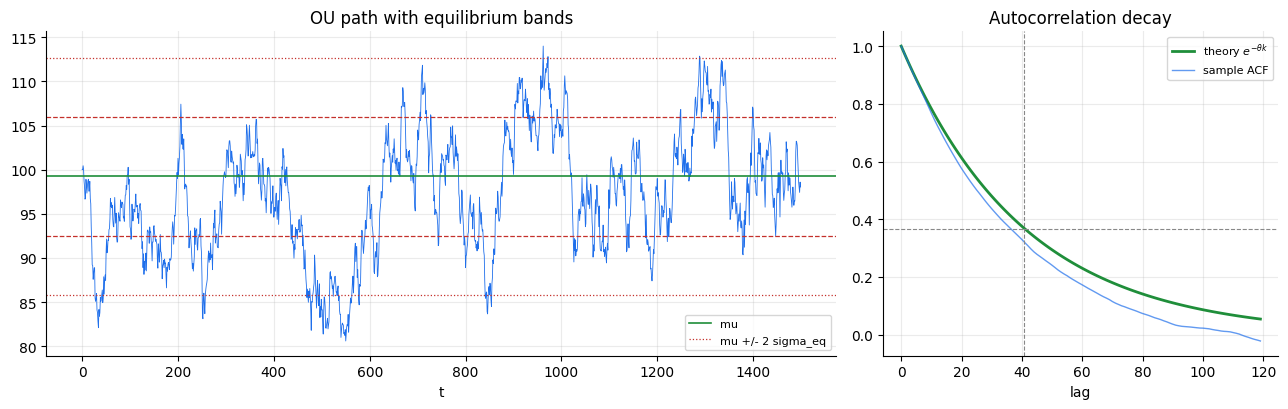

relaxation time 1/theta = 40.8 days   half-life = 28.3 days


In [3]:
ou = fit_mle  # use the fitted model
mu, seq = ou.mu, ou.stationary_std
fig, (axp, axa) = plt.subplots(1, 2, figsize=(13, 4.2), gridspec_kw={'width_ratios': [2, 1]})
axp.plot(path[:1500], color='#1f6feb', lw=0.6)
axp.axhline(mu, color='#1f8e3a', lw=1.2, label='mu')
for k, ls in [(1, '--'), (2, ':')]:
    axp.axhline(mu + k*seq, color='#c4302b', lw=0.9, ls=ls)
    axp.axhline(mu - k*seq, color='#c4302b', lw=0.9, ls=ls,
                label=f'mu +/- {k} sigma_eq' if k == 2 else None)
axp.set_title('OU path with equilibrium bands'); axp.set_xlabel('t'); axp.legend(fontsize=8)

lags = np.arange(0, 120)
theo = np.array([ou.autocorrelation(int(k)) for k in lags])
x = path - path.mean()
samp = np.array([1.0] + [np.dot(x[:-k], x[k:]) / np.dot(x, x) for k in range(1, 120)])
axa.plot(lags, theo, color='#1f8e3a', lw=2, label='theory $e^{-\\theta k}$')
axa.plot(lags, samp, color='#1f6feb', lw=1, alpha=0.7, label='sample ACF')
axa.axhline(1/np.e, color='#888', ls='--', lw=0.8); axa.axvline(1/ou.theta, color='#888', ls='--', lw=0.8)
axa.set_title('Autocorrelation decay'); axa.set_xlabel('lag'); axa.legend(fontsize=8)
plt.tight_layout(); plt.show()
print(f'relaxation time 1/theta = {1/ou.theta:.1f} days   half-life = {ou.half_life:.1f} days')


## 3. The z-score signal

Mean-reversion trading reduces to one number: the **z-score**
$z_t=(X_t-\mu)/\sigma_{eq}$. Fade extremes — **short** when $z$ is high,
**long** when low, **exit** near zero. The model also quantifies the edge:

* `band_probability(lo, hi)` — stationary probability of sitting inside a band.
* `expected_crossing_time(x0)` — expected time to revert to $\mu$ from $x_0$.


P(|z| < 1) = 68.3%   P(|z| > 2) = 4.6%
from z=1: expected reversion time ~  28.3 days
from z=2: expected reversion time ~  44.9 days
from z=3: expected reversion time ~  56.6 days


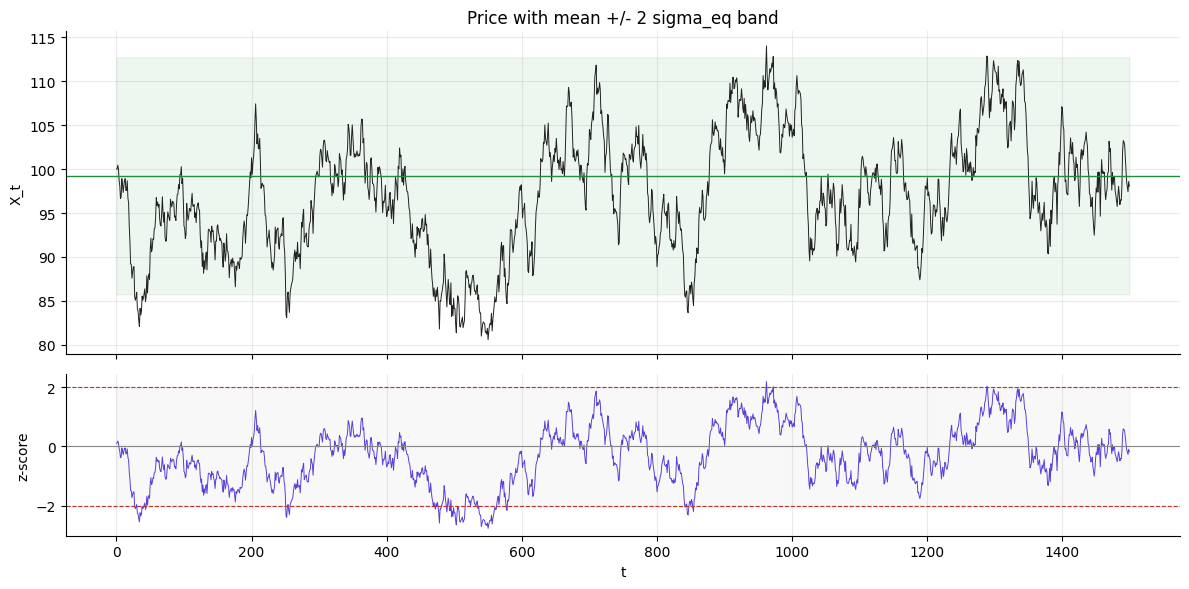

In [4]:
z = ou.z_score(path)
print(f'P(|z| < 1) = {ou.band_probability(mu - seq, mu + seq):.1%}   '
      f'P(|z| > 2) = {1 - ou.band_probability(mu - 2*seq, mu + 2*seq):.1%}')
for z0 in (1.0, 2.0, 3.0):
    t_rev = ou.expected_crossing_time(mu + z0 * seq)
    print(f'from z={z0:.0f}: expected reversion time ~ {t_rev:5.1f} days')

fig, (axp, axz) = plt.subplots(2, 1, sharex=True, height_ratios=[2, 1], figsize=(12, 6))
seg = slice(0, 1500)
axp.plot(path[seg], color='#222', lw=0.7); axp.axhline(mu, color='#1f8e3a', lw=1)
axp.fill_between(range(1500), mu - 2*seq, mu + 2*seq, color='#1f8e3a', alpha=0.08)
axp.set_title('Price with mean +/- 2 sigma_eq band'); axp.set_ylabel('X_t')
axz.plot(z[seg], color='#5b3fd8', lw=0.7)
for lvl, c in [(2, '#c4302b'), (-2, '#c4302b'), (0, '#888')]:
    axz.axhline(lvl, color=c, lw=0.8, ls='--' if lvl else '-')
axz.fill_between(range(1500), -2, 2, color='gray', alpha=0.05)
axz.set_ylabel('z-score'); axz.set_xlabel('t')
plt.tight_layout(); plt.show()


## 4. A real mean-reverting series — the KO/PEP ratio

Coca-Cola (KO) and PepsiCo (PEP) are economic twins, so their **price ratio**
hovers around a slowly-moving level — a textbook mean-reverting, positive series
that is also a *tradeable* long-short pair (long the ratio = long KO / short PEP).
We fit OU, read the half-life, and check mean reversion with an ADF test.


In [5]:
def load_ratio(a='KO', b='PEP', start='2012-01-01', end='2024-12-31'):
    try:
        import yfinance as yf
        raw = yf.download([a, b], start=start, end=end, auto_adjust=True, progress=False)
        close = raw['Close'][[a, b]].dropna()
        if len(close) > 800:
            px = close.to_numpy(dtype='float64')
            return px[:, 0] / px[:, 1]
    except Exception as exc:
        print(f'yfinance unavailable ({exc!r}); using synthetic mean-reverting ratio')
    ou_syn = OrnsteinUhlenbeck(theta=np.log(2)/40, mu=2.1, sigma=0.05, dt=1.0)
    return ou_syn.simulate(n_steps=3000, x0=2.1, seed=3)

ratio = load_ratio()
ou_r = OrnsteinUhlenbeck(dt=1.0); rr = ou_r.fit(ratio, method='mle')
adf_r = adf(ratio, regression='c')
print(rr)
print(f'\nADF on the ratio: tau={adf_r.stat:.3f}  p={adf_r.p_value:.3f}  -> '
      f'{"mean-reverting (reject unit root)" if adf_r.p_value < 0.1 else "weak/none"}')
print(f'spread half-life (AR(1) on diffs) = {half_life(ratio):.1f} days')


Ornstein-Uhlenbeck Fit
  method      : mle
  n_obs       : 3268
  θ  (speed)  : 0.002534
  μ  (mean)   : 0.400839
  σ  (vol)    : 0.003396
  half-life   : 273.5489
  σ_eq        : 0.047703
  log-lik     : 13946.2344

ADF on the ratio: tau=-2.227  p=0.124  -> weak/none
spread half-life (AR(1) on diffs) = 273.9 days


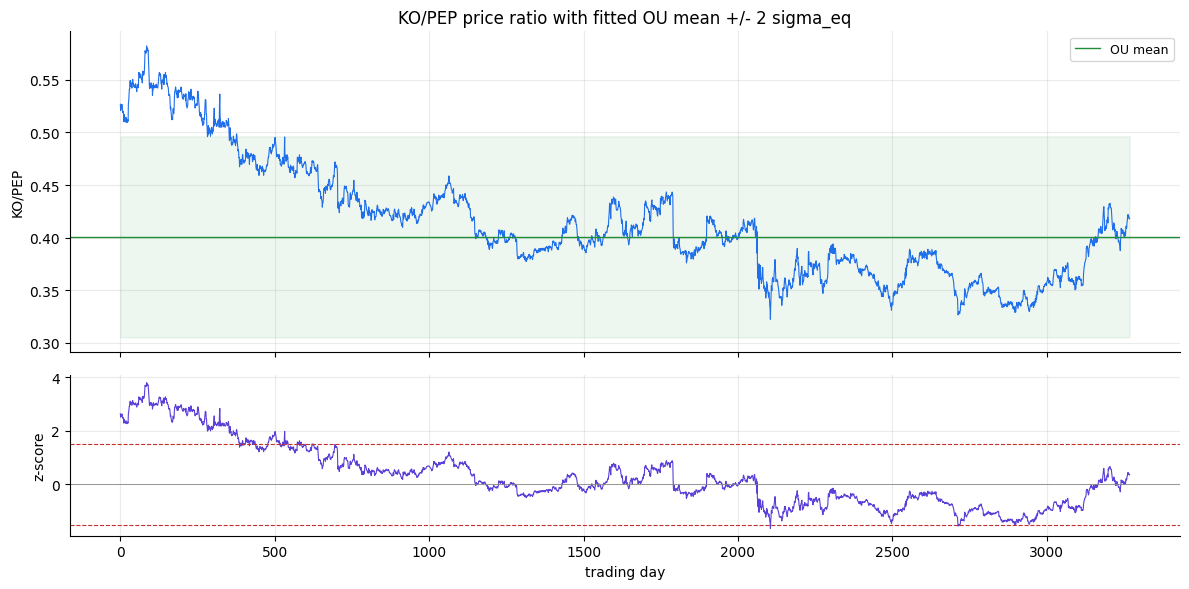

In [6]:
mu_r, seq_r = ou_r.mu, ou_r.stationary_std
zz = ou_r.z_score(ratio)
fig, (axp, axz) = plt.subplots(2, 1, sharex=True, height_ratios=[2, 1], figsize=(12, 6))
axp.plot(ratio, color='#1f6feb', lw=0.8); axp.axhline(mu_r, color='#1f8e3a', lw=1, label='OU mean')
axp.fill_between(range(len(ratio)), mu_r - 2*seq_r, mu_r + 2*seq_r, color='#1f8e3a', alpha=0.08)
axp.set_title('KO/PEP price ratio with fitted OU mean +/- 2 sigma_eq'); axp.set_ylabel('KO/PEP'); axp.legend(fontsize=9)
axz.plot(zz, color='#5b3fd8', lw=0.8); axz.axhline(0, color='#888', lw=0.6)
axz.axhline(1.5, color='#c4302b', ls='--', lw=0.8); axz.axhline(-1.5, color='#c4302b', ls='--', lw=0.8)
axz.set_ylabel('z-score'); axz.set_xlabel('trading day')
plt.tight_layout(); plt.show()


## 5. Hand-off — the adaptive `MeanReversionStrategy`

The fixed-parameter OU fit above is *in-sample*. A live strategy must estimate
$\theta_t,\mu_t,\sigma_{eq,t}$ **causally**. `MeanReversionStrategy` does this
with a Kalman filter that tracks a time-varying AR(1), turns it into a rolling
z-score, and trades entry/exit/stop bands. `fit()` then tunes the thresholds.


In [7]:
strat = MeanReversionStrategy(StrategyParams(entry_z=1.5, exit_z=0.5, stop_z=3.5, vol_window=60))
base = strat.run(ratio)
print('Default parameters:')
print(base.summary())

train = strat.fit(ratio, method='sharpe', n_restarts=3)
tuned = strat.run(ratio)
print('\nAfter fit(method="sharpe"):')
print(tuned.summary())


Default parameters:
Backtest Summary
  Sharpe (ann.) : 0.2994
  Total return  : 14.93%
  Max drawdown  : -9.02%
  Num trades    : 7
  Avg half-life : 26.48
  Avg |z_score| : 0.574



After fit(method="sharpe"):
Backtest Summary
  Sharpe (ann.) : 0.8640
  Total return  : 87.34%
  Max drawdown  : -12.17%
  Num trades    : 68
  Avg half-life : 26.66
  Avg |z_score| : 0.929


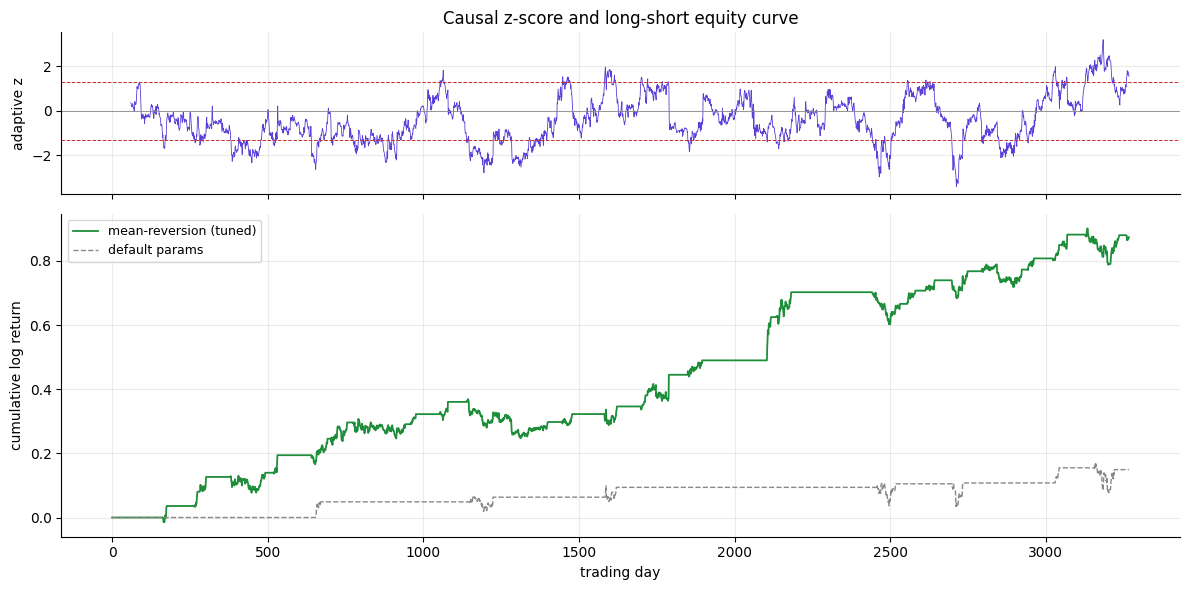

In [8]:
fig, (axz, axe) = plt.subplots(2, 1, sharex=True, height_ratios=[1, 2], figsize=(12, 6))
axz.plot(tuned.z_score, color='#5b3fd8', lw=0.6); axz.axhline(0, color='#888', lw=0.6)
axz.axhline(strat.params.entry_z, color='#c4302b', ls='--', lw=0.7)
axz.axhline(-strat.params.entry_z, color='#c4302b', ls='--', lw=0.7)
axz.set_ylabel('adaptive z'); axz.set_title('Causal z-score and long-short equity curve')
axe.plot(np.nancumsum(tuned.log_returns), color='#1f8e3a', lw=1.3, label='mean-reversion (tuned)')
axe.plot(np.nancumsum(base.log_returns), color='#888', lw=1.0, ls='--', label='default params')
axe.set_ylabel('cumulative log return'); axe.set_xlabel('trading day'); axe.legend(fontsize=9)
plt.tight_layout(); plt.show()


## What next?

* **It's a pair trade.** Trading the KO/PEP *ratio* is a hedge-ratio-of-1
  special case. The general case — estimating $\beta$, testing cointegration
  rigorously (Engle–Granger / Johansen), and a Kalman dynamic hedge — is the
  **cointegration & pairs** tutorial.
* **Half-life is a filter.** Screen a universe and keep only pairs whose
  half-life is short enough to trade but long enough to beat costs.
* **Regimes break reversion.** A structural break sends $\theta\to 0$; gate the
  signal with a regime model (`qufin.timeseries.MarkovSwitchingAR`) or a
  rolling ADF to stand aside when reversion dies.
